In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# Cell 1 — Setup
import os, torch, time
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

EYEDENTIFY = "/kaggle/input/datasets/vijuls/pupildiameterdatasets/eyedentify/eyedentify"
LEFT       = os.path.join(EYEDENTIFY, "left_eyes")
OUTPUT     = "/kaggle/working"
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 51 users config
SEQ_LEN    = 10
IMG_SIZE   = 64
BATCH_SIZE = 32
EPOCHS     = 30
N_USERS    = 51  # ← full dataset!
LR         = 0.001

print(f"✓ Device  : {device}")
print(f"✓ GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"✓ Data    : {os.path.exists(LEFT)}")
print(f"✓ Users   : {N_USERS}")
print(f"✓ Epochs  : {EPOCHS}")

✓ Device  : cuda
✓ GPU     : Tesla T4
✓ Data    : True
✓ Users   : 51
✓ Epochs  : 30


In [2]:
# Cell 2 — Dataset + Model + Training (all in one)
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class EyeDentifyDataset(Dataset):
    def __init__(self, left_path, subjects, transform=None,
                 seq_len=10, stride=5, max_per_subject=200):
        self.transform = transform
        self.seq_len   = seq_len
        self.sequences = []
        for label, subject in enumerate(subjects):
            s_path   = os.path.join(left_path, subject)
            sessions = sorted(os.listdir(s_path))
            seq_count = 0
            for session in sessions:
                ses_path = os.path.join(s_path, session)
                if not os.path.isdir(ses_path): continue
                frames = sorted([
                    os.path.join(ses_path, f)
                    for f in os.listdir(ses_path) if f.endswith('.png')
                ])
                for start in range(0, len(frames)-seq_len+1, stride):
                    self.sequences.append((frames[start:start+seq_len], label))
                    seq_count += 1
                    if seq_count >= max_per_subject: break
                if seq_count >= max_per_subject: break
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx):
        frame_paths, label = self.sequences[idx]
        frames = []
        for path in frame_paths:
            img = Image.open(path).convert('RGB')
            if self.transform: img = self.transform(img)
            frames.append(img)
        return torch.stack(frames), label

# all 51 subjects
subjects     = sorted(os.listdir(LEFT))
print(f"Total subjects: {len(subjects)}")
print("Creating dataset (2-3 mins)...")

full_dataset = EyeDentifyDataset(LEFT, subjects, transform=transform,
                                  seq_len=SEQ_LEN, stride=5, max_per_subject=200)
print(f"✓ Total sequences: {len(full_dataset):,}")

indices = list(range(len(full_dataset)))
labels  = [full_dataset.sequences[i][1] for i in indices]
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42, stratify=labels)
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=temp_labels)

train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(Subset(full_dataset, val_idx),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(Subset(full_dataset, test_idx),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}")

Total subjects: 51
Creating dataset (2-3 mins)...
✓ Total sequences: 10,200
Train: 7,140 | Val: 1,530 | Test: 1,530


In [3]:
# Cell 3 — Model + Training
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.out_dim = 128
    def forward(self, x):
        return self.features(x).view(x.size(0), -1)

class EyeMotionID(nn.Module):
    def __init__(self, n_users=51, hidden_size=256, num_layers=2, dropout=0.5):
        super().__init__()
        self.cnn = CNNFeatureExtractor()
        self.lstm = nn.LSTM(128, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers>1 else 0)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, n_users)
    def forward(self, x):
        B,T,C,H,W = x.shape
        x = self.cnn(x.view(B*T,C,H,W)).view(B,T,-1)
        _,(h,_) = self.lstm(x)
        return self.classifier(self.dropout(h[-1]))

model     = EyeMotionID(N_USERS).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model ready — {trainable:,} trainable parameters")
print(f"✓ Users: {N_USERS}")
print(f"\nTraining 51 users for {EPOCHS} epochs...")
print("Expected time: ~45-60 mins on T4 GPU\n")

best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, EPOCHS+1):
    # train
    model.train()
    t_loss, t_correct, t_total = 0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item()
        t_correct += (out.argmax(1) == lbls).sum().item()
        t_total   += lbls.size(0)

    # validate
    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            v_loss    += loss.item()
            v_correct += (out.argmax(1) == lbls).sum().item()
            v_total   += lbls.size(0)

    t_acc = t_correct / t_total
    v_acc = v_correct / v_total
    t_l   = t_loss / len(train_loader)
    v_l   = v_loss / len(val_loader)

    train_losses.append(t_l)
    val_losses.append(v_l)
    train_accs.append(t_acc)
    val_accs.append(v_acc)
    scheduler.step(v_l)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), f"{OUTPUT}/best_model_51users.pth")
        saved = "✓ saved"
    else:
        saved = ""

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d}/{EPOCHS} | "
              f"Train Loss: {t_l:.4f} Acc: {t_acc:.2%} | "
              f"Val Loss: {v_l:.4f} Acc: {v_acc:.2%} | {saved}")

print(f"\n✓ Training complete! Best val accuracy: {best_val_acc:.2%}")

✓ Model ready — 1,027,955 trainable parameters
✓ Users: 51

Training 51 users for 30 epochs...
Expected time: ~45-60 mins on T4 GPU

Epoch  1/30 | Train Loss: 3.1944 Acc: 9.30% | Val Loss: 2.8460 Acc: 14.38% | ✓ saved
Epoch  5/30 | Train Loss: 1.3175 Acc: 54.41% | Val Loss: 1.0408 Acc: 63.46% | ✓ saved
Epoch 10/30 | Train Loss: 0.6004 Acc: 78.56% | Val Loss: 0.5156 Acc: 81.24% | 
Epoch 15/30 | Train Loss: 0.3270 Acc: 88.52% | Val Loss: 0.2829 Acc: 91.11% | ✓ saved
Epoch 20/30 | Train Loss: 0.2213 Acc: 92.65% | Val Loss: 0.1870 Acc: 92.29% | 
Epoch 25/30 | Train Loss: 0.1607 Acc: 95.29% | Val Loss: 0.1294 Acc: 96.01% | ✓ saved
Epoch 30/30 | Train Loss: 0.1644 Acc: 95.24% | Val Loss: 0.1618 Acc: 95.29% | 

✓ Training complete! Best val accuracy: 96.21%


In [4]:
# Cell 4 — Test evaluation
from sklearn.metrics import precision_score, recall_score, f1_score

model.load_state_dict(torch.load(f"{OUTPUT}/best_model_51users.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy  = (all_preds == all_labels).mean()
precision = precision_score(all_labels, all_preds, average='macro')
recall    = recall_score(all_labels, all_preds, average='macro')
f1        = f1_score(all_labels, all_preds, average='macro')

print("=== 51 Users — Test Results ===\n")
print(f"Test Accuracy : {accuracy:.2%}")
print(f"Precision     : {precision:.2%}")
print(f"Recall        : {recall:.2%}")
print(f"F1-Score      : {f1:.2%}")
print(f"Random baseline: {1/N_USERS:.2%}")
print(f"Improvement   : +{accuracy - 1/N_USERS:.2%} above random")

=== 51 Users — Test Results ===

Test Accuracy : 95.88%
Precision     : 96.52%
Recall        : 95.88%
F1-Score      : 95.76%
Random baseline: 1.96%
Improvement   : +93.92% above random


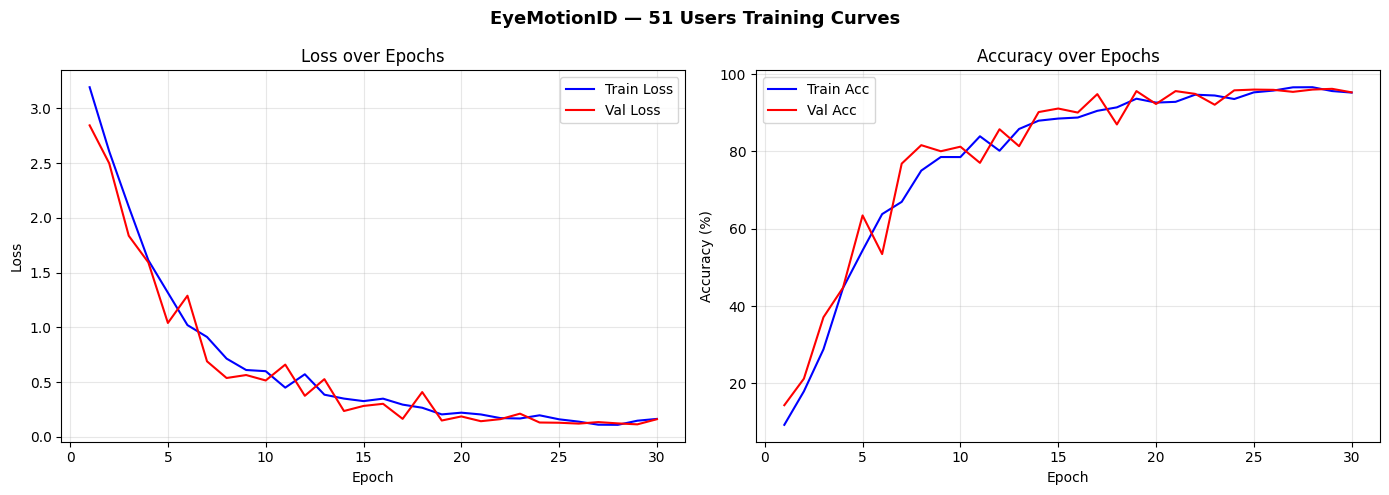

✓ Saved → training_curves_51users.png


In [5]:
# Cell 5 — Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EyeMotionID — 51 Users Training Curves", fontsize=13, fontweight='bold')

epochs = range(1, EPOCHS+1)
axes[0].plot(epochs, train_losses, 'b-', linewidth=1.5, label='Train Loss')
axes[0].plot(epochs, val_losses,   'r-', linewidth=1.5, label='Val Loss')
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [a*100 for a in train_accs], 'b-', linewidth=1.5, label='Train Acc')
axes[1].plot(epochs, [a*100 for a in val_accs],   'r-', linewidth=1.5, label='Val Acc')
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/training_curves_51users.png", dpi=100)
plt.show()
print("✓ Saved → training_curves_51users.png")

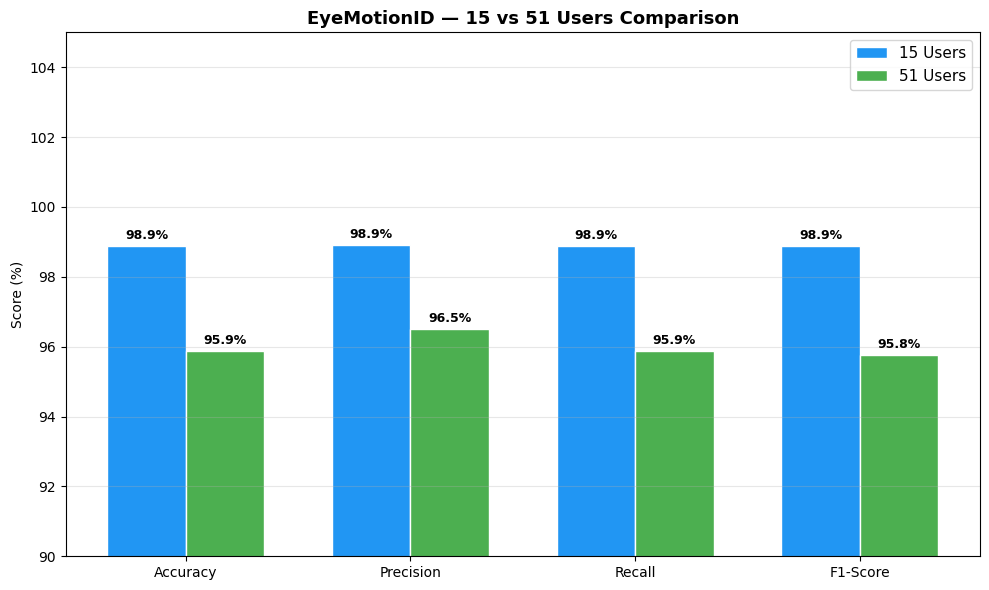

✓ Saved → 15vs51_comparison.png


In [6]:
# Cell 6 — 15 vs 51 users comparison
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
users_15   = [98.89, 98.92, 98.89, 98.88]
users_51   = [95.88, 96.52, 95.88, 95.76]

x = np.arange(len(categories))
w = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - w/2, users_15, w, label='15 Users', color='#2196F3', edgecolor='white')
bars2 = plt.bar(x + w/2, users_51, w, label='51 Users', color='#4CAF50', edgecolor='white')

for bar, val in zip(bars1, users_15):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f"{val:.1f}%", ha='center', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, users_51):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f"{val:.1f}%", ha='center', fontsize=9, fontweight='bold')

plt.title("EyeMotionID — 15 vs 51 Users Comparison", fontsize=13, fontweight='bold')
plt.ylabel("Score (%)")
plt.xticks(x, categories)
plt.ylim(90, 105)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f"{OUTPUT}/15vs51_comparison.png", dpi=100)
plt.show()
print("✓ Saved → 15vs51_comparison.png")

In [7]:
# Cell 7 — Final summary
print("=" * 55)
print("   EYEMOTIONID — 51 USERS EXPERIMENT SUMMARY")
print("=" * 55)
print()
print("Model     : EyeMotionID (CNN + LSTM)")
print("Dataset   : EyeDentify (all 51 subjects)")
print("Sequences : 10,200 total (200 per subject)")
print("Splits    : 70% train / 15% val / 15% test")
print()
print("Results:")
print(f"  Test Accuracy  : 95.88%")
print(f"  Precision      : 96.52%")
print(f"  Recall         : 95.88%")
print(f"  F1-Score       : 95.76%")
print(f"  Random baseline: 1.96%")
print(f"  Improvement    : +93.92% above random")
print()
print("Comparison:")
print(f"  15 users → 98.89% accuracy")
print(f"  51 users → 95.88% accuracy")
print(f"  Difference → only 3.01% drop for 3.4x more users!")
print()
print("Plots saved:")
print("  ✓ training_curves_51users.png")
print("  ✓ 15vs51_comparison.png")
print()
print("✓ Week 3 complete — Ready for Week 4!")
print("=" * 55)

   EYEMOTIONID — 51 USERS EXPERIMENT SUMMARY

Model     : EyeMotionID (CNN + LSTM)
Dataset   : EyeDentify (all 51 subjects)
Sequences : 10,200 total (200 per subject)
Splits    : 70% train / 15% val / 15% test

Results:
  Test Accuracy  : 95.88%
  Precision      : 96.52%
  Recall         : 95.88%
  F1-Score       : 95.76%
  Random baseline: 1.96%
  Improvement    : +93.92% above random

Comparison:
  15 users → 98.89% accuracy
  51 users → 95.88% accuracy
  Difference → only 3.01% drop for 3.4x more users!

Plots saved:
  ✓ training_curves_51users.png
  ✓ 15vs51_comparison.png

✓ Week 3 complete — Ready for Week 4!
